## Churn Prediction Using ANN

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [54]:
df = pd.read_csv('./datasets/Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5645,5646,15785373,Wong,717,Spain,Female,42,5,190305.78,1,1,0,99347.80,1
2301,2302,15757577,Odili,676,France,Female,61,8,0.00,2,1,1,118522.73,0
3693,3694,15722246,Omeokachie,742,France,Female,60,4,0.00,1,1,1,13161.66,1
532,533,15663478,Baldwin,729,France,Male,32,6,93694.42,1,1,1,79919.13,0
1960,1961,15623647,Dellucci,655,Spain,Female,36,1,135515.76,1,1,0,86013.96,0


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [58]:
df = df.iloc[:, 3:]

In [59]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [60]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [61]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [62]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [63]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=['Exited']), df['Exited'], test_size=0.2, random_state=149)

In [64]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [65]:
x_train.shape

(8000, 11)

### ANN

In [66]:
model = Sequential()
model.add(Dense(5, activation='relu', input_dim=11))
model.add(Dense(1, activation='sigmoid'))

D:\Deep Learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense_6 (Dense)              │ (None, 5)             │           60 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense_7 (Dense)              │ (None, 1)             │            6 │
└──────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 66 (264.00 B)

 Trainable params: 66 (264.00 B)

 Non-trainable params: 0 (0.00 B)

In [68]:
model.compile(metrics=['accuracy'], optimizer='Adam', loss='binary_crossentropy')

In [69]:
history = model.fit(x_train, y_train, batch_size=50, epochs=30, verbose=2, validation_split=0.2)

Epoch 1/30
128/128 - 1s - 6ms/step - accuracy: 0.5714 - loss: 0.7602 - val_accuracy: 0.6750 - val_loss: 0.6419
Epoch 2/30
128/128 - 0s - 2ms/step - accuracy: 0.7220 - loss: 0.5753 - val_accuracy: 0.7650 - val_loss: 0.5383
Epoch 3/30
128/128 - 0s - 1ms/step - accuracy: 0.7833 - loss: 0.5010 - val_accuracy: 0.7887 - val_loss: 0.4957
Epoch 4/30
128/128 - 0s - 1ms/step - accuracy: 0.7948 - loss: 0.4699 - val_accuracy: 0.8012 - val_loss: 0.4737
Epoch 5/30
128/128 - 0s - 1ms/step - accuracy: 0.7984 - loss: 0.4530 - val_accuracy: 0.8081 - val_loss: 0.4595
Epoch 6/30
128/128 - 0s - 1ms/step - accuracy: 0.8041 - loss: 0.4417 - val_accuracy: 0.8106 - val_loss: 0.4494
Epoch 7/30
128/128 - 0s - 1ms/step - accuracy: 0.8067 - loss: 0.4330 - val_accuracy: 0.8112 - val_loss: 0.4414
Epoch 8/30
128/128 - 0s - 1ms/step - accuracy: 0.8095 - loss: 0.4261 - val_accuracy: 0.8138 - val_loss: 0.4348
Epoch 9/30
128/128 - 0s - 1ms/step - accuracy: 0.8141 - loss: 0.4206 - val_accuracy: 0.8169 - val_loss: 0.4290
E

In [70]:
y_pred = model.predict(x_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 954us/step


In [79]:
accuracy_score(y_test, y_pred.argmax(axis=1))

0.801

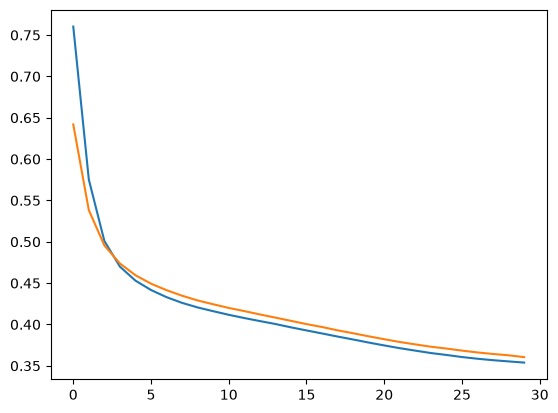

In [84]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [ ]:
plt.plot(history.history['accuracy'])
plt.s